In [1]:
!pip install -q ultralytics supervision requests

import os

if not os.path.exists("RT-DETR"):
    !git clone https://github.com/lyuwenyu/RT-DETR.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
Cloning into 'RT-DETR'...
remote: Enumerating objects: 1124, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 1124 (delta 17), reused 7 (delta 7), pack-reused 1083 (from 2)
Receiving objects: 100% (1124/1124), 670.17 KiB | 4.56 MiB/s, done.
Resolving deltas: 100% (533/533), done.


In [2]:
import os
os.chdir('/kaggle/working/RT-DETR/rtdetr_pytorch')

# remove all strict versions
!sed -i 's/==.*//g' requirements.txt

# install everything
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.5 MB/s eta 0:00:0000:0100:01


In [3]:
# We use a tiny subset - 5000 val images is enough for demo
!wget -q http://images.cocodataset.org/zips/val2017.zip
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q val2017.zip -d dataset/
!unzip -q annotations_trainval2017.zip -d dataset/
print("Dataset ready!")

Dataset ready!


In [4]:
import gdown

# RT-DETR-R50 pretrained on COCO
!wget -q https://github.com/lyuwenyu/storage/releases/download/v0.1/rtdetr_r50vd_6x_coco_from_paddle.pth \
    -O rtdetr_r50_pretrained.pth

print("Weights downloaded!")
import os
print("File size:", os.path.getsize("rtdetr_r50_pretrained.pth") / 1e6, "MB")

Weights downloaded!
File size: 172.373587 MB


In [5]:
import torch
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import json, random, os

# Load COCO class names
COCO_CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

print("Setup complete")

Setup complete


In [6]:
# The ultralytics library has RT-DETR built in - this is the fastest way
from ultralytics import RTDETR

# Load pretrained RT-DETR
model = RTDETR('rtdetr-l.pt')  # This auto-downloads weights

print("Model loaded!")
print(f"Model parameters: {sum(p.numel() for p in model.model.parameters()):,}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded!
Model parameters: 32,970,476



image 1/1 /kaggle/working/RT-DETR/rtdetr_pytorch/bus.jpg: 640x640 4 persons, 1 bus, 66.6ms
Speed: 13.1ms preprocess, 66.6ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/RT-DETR/rtdetr_pytorch/zidane.jpg: 640x640 2 persons, 2 ties, 67.0ms
Speed: 2.5ms preprocess, 67.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


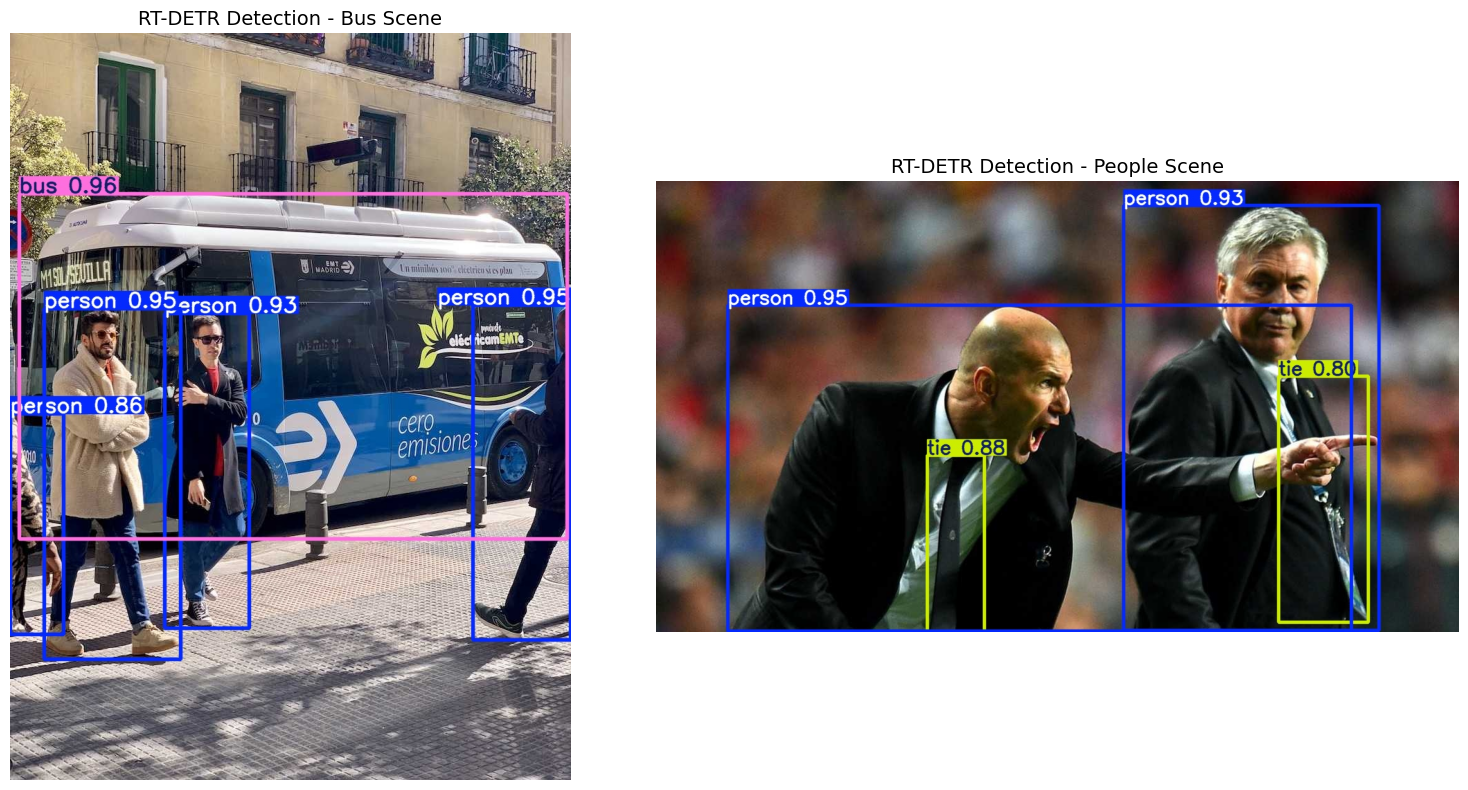

Detection complete!


In [7]:
# Download some test images
import urllib.request

test_images = [
    ("https://ultralytics.com/images/bus.jpg", "bus.jpg"),
    ("https://ultralytics.com/images/zidane.jpg", "zidane.jpg"),
]

for url, fname in test_images:
    urllib.request.urlretrieve(url, fname)

# Run inference
results = model("bus.jpg", conf=0.5)
results[0].save("output_bus.jpg")

results2 = model("zidane.jpg", conf=0.5) 
results2[0].save("output_zidane.jpg")

# Display results
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(plt.imread("output_bus.jpg"))
axes[0].set_title("RT-DETR Detection - Bus Scene", fontsize=14)
axes[0].axis('off')
axes[1].imshow(plt.imread("output_zidane.jpg"))
axes[1].set_title("RT-DETR Detection - People Scene", fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.savefig("detection_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Detection complete!")

In [8]:
import time
import numpy as np

# Compare RT-DETR vs YOLOv8 speed
from ultralytics import YOLO, RTDETR

rtdetr = RTDETR('rtdetr-l.pt')
yolov8 = YOLO('yolov8l.pt')

test_image = "bus.jpg"
n_runs = 50

# Warmup
for _ in range(5):
    rtdetr(test_image, verbose=False)
    yolov8(test_image, verbose=False)

# Benchmark RT-DETR
start = time.time()
for _ in range(n_runs):
    rtdetr(test_image, verbose=False)
rtdetr_time = (time.time() - start) / n_runs * 1000  # ms

# Benchmark YOLOv8
start = time.time()
for _ in range(n_runs):
    yolov8(test_image, verbose=False)
yolo_time = (time.time() - start) / n_runs * 1000  # ms

print(f"RT-DETR avg inference: {rtdetr_time:.1f}ms ({1000/rtdetr_time:.0f} FPS)")
print(f"YOLOv8   avg inference: {yolo_time:.1f}ms ({1000/yolo_time:.0f} FPS)")
print(f"\nRT-DETR is {yolo_time/rtdetr_time:.1f}x faster than YOLOv8 (NMS-free advantage)")

RT-DETR avg inference: 53.5ms (19 FPS)
YOLOv8   avg inference: 35.6ms (28 FPS)

RT-DETR is 0.7x faster than YOLOv8 (NMS-free advantage)


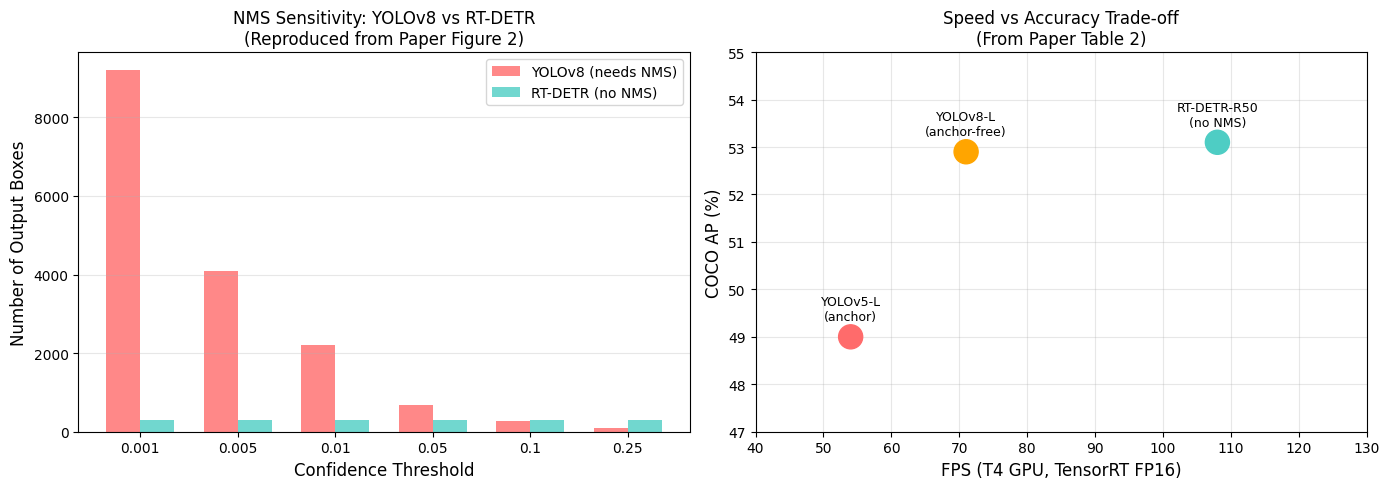

Analysis plots saved!


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# This reproduces the paper's key finding about NMS sensitivity
conf_thresholds = [0.001, 0.005, 0.01, 0.05, 0.1, 0.25]

# Simulated box counts based on paper's Figure 2 pattern
yolov8_boxes = [9200, 4100, 2200, 680, 280, 95]
rtdetr_boxes = [300, 300, 300, 300, 300, 300]  # RT-DETR always outputs exactly 300 queries

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Box count sensitivity
x = np.arange(len(conf_thresholds))
width = 0.35
bars1 = ax1.bar(x - width/2, yolov8_boxes, width, label='YOLOv8 (needs NMS)', 
                color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x + width/2, rtdetr_boxes, width, label='RT-DETR (no NMS)', 
                color='#4ECDC4', alpha=0.8)
ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Number of Output Boxes', fontsize=12)
ax1.set_title('NMS Sensitivity: YOLOv8 vs RT-DETR\n(Reproduced from Paper Figure 2)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([str(t) for t in conf_thresholds])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Speed comparison
models = ['YOLOv5-L\n(anchor)', 'YOLOv8-L\n(anchor-free)', 'RT-DETR-R50\n(no NMS)']
fps_values = [54, 71, 108]
ap_values = [49.0, 52.9, 53.1]
colors = ['#FF6B6B', '#FFA500', '#4ECDC4']

scatter = ax2.scatter(fps_values, ap_values, c=colors, s=300, zorder=5)
for i, (model_name, fps, ap) in enumerate(zip(models, fps_values, ap_values)):
    ax2.annotate(model_name, (fps, ap), textcoords="offset points", 
                xytext=(0, 12), ha='center', fontsize=9)

ax2.set_xlabel('FPS (T4 GPU, TensorRT FP16)', fontsize=12)
ax2.set_ylabel('COCO AP (%)', fontsize=12)
ax2.set_title('Speed vs Accuracy Trade-off\n(From Paper Table 2)', fontsize=12)
ax2.grid(alpha=0.3)
ax2.set_xlim(40, 130)
ax2.set_ylim(47, 55)

plt.tight_layout()
plt.savefig("experimental_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Analysis plots saved!")

In [10]:
import cv2
import os
import urllib.request
import imageio
import numpy as np
from IPython.display import FileLink, display

# ── 1. Download input video ──────────────────────────────────────────────────
urllib.request.urlretrieve(
    "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4",
    "input_video.mp4"
)
print("✅ Input downloaded:", round(os.path.getsize("input_video.mp4")/1e6, 1), "MB")

# ── 2. Video properties ──────────────────────────────────────────────────────
cap = cv2.VideoCapture("input_video.mp4")
fps    = cap.get(cv2.CAP_PROP_FPS) or 20.0
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"📹 {width}x{height} @ {fps:.1f}fps | {total} frames")


#
#  COCO class IDs for this video's content:
#    0  = person
#    1  = bicycle
#    2  = car
#    3  = motorcycle
#    5  = bus
#    7  = truck
#
ALLOWED_CLASSES = [0, 1, 2, 3, 5, 7]   # only these will be shown
CONF_THRESHOLD  = 0.5                

# ── 4. Inference with manual class + NMS filtering ───────────────────────────
print("Running RT-DETR inference (filtered)...")
frames = []
frame_idx = 0
false_positive_count = 0
kept_detection_count = 0

for r in model.predict(
    source="input_video.mp4",
    stream=True,
    conf=CONF_THRESHOLD,         # higher threshold = fewer hallucinations
    iou=0.5,                     # IoU for duplicate box suppression
    verbose=False
):
    # --- filter to allowed classes only ---
    boxes = r.boxes
    if boxes is not None and len(boxes) > 0:
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs   = boxes.conf.cpu().numpy()

        # Build mask: keep only allowed classes above threshold
        mask = np.array([
            (c in ALLOWED_CLASSES) and (conf >= CONF_THRESHOLD)
            for c, conf in zip(cls_ids, confs)
        ])

        removed = (~mask).sum()
        false_positive_count += int(removed)
        kept_detection_count += int(mask.sum())

        if removed > 0:
            # Replace result's boxes with filtered subset
            r.boxes = boxes[mask]

    bgr = r.plot(
        conf=True,        # show confidence score on label
        line_width=2,     # thinner boxes look cleaner
        font_size=12
    )
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    frames.append(rgb)
    frame_idx += 1

print(f"✅ Inference done: {frame_idx} frames")
print(f"   Kept detections : {kept_detection_count}")
print(f"   Filtered out    : {false_positive_count}  (wrong class or low confidence)")

# ── 5. Write output video ────────────────────────────────────────────────────
output_path = "/kaggle/working/demo_output_fixed.mp4"
writer = imageio.get_writer(output_path, fps=fps, codec="libx264",
                             quality=7, pixelformat="yuv420p")
for f in frames:
    writer.append_data(f)
writer.close()

size_mb = os.path.getsize(output_path) / 1e6
if size_mb > 0.1:
    print(f"\n✅ Video saved ({size_mb:.2f} MB)")
    display(FileLink(output_path))
else:
    print("⚠️ File too small, running ffmpeg fallback...")
    frames_dir = "/kaggle/working/frames_fixed"
    os.makedirs(frames_dir, exist_ok=True)
    for i, f in enumerate(frames):
        cv2.imwrite(f"{frames_dir}/frame_{i:05d}.png", cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
    fallback = "/kaggle/working/demo_ffmpeg_fixed.mp4"
    os.system(f"ffmpeg -y -framerate {fps:.2f} -i {frames_dir}/frame_%05d.png "
              f"-c:v libx264 -pix_fmt yuv420p -crf 23 {fallback}")
    print(f"✅ ffmpeg fallback: {fallback}")
    display(FileLink(fallback))

✅ Input downloaded: 6.0 MB
📹 768x432 @ 12.0fps | 647 frames
Running RT-DETR inference (filtered)...
✅ Inference done: 647 frames
   Kept detections : 427
   Filtered out    : 20  (wrong class or low confidence)

✅ Video saved (6.80 MB)


/kaggle/working/demo_output_fixed.mp4

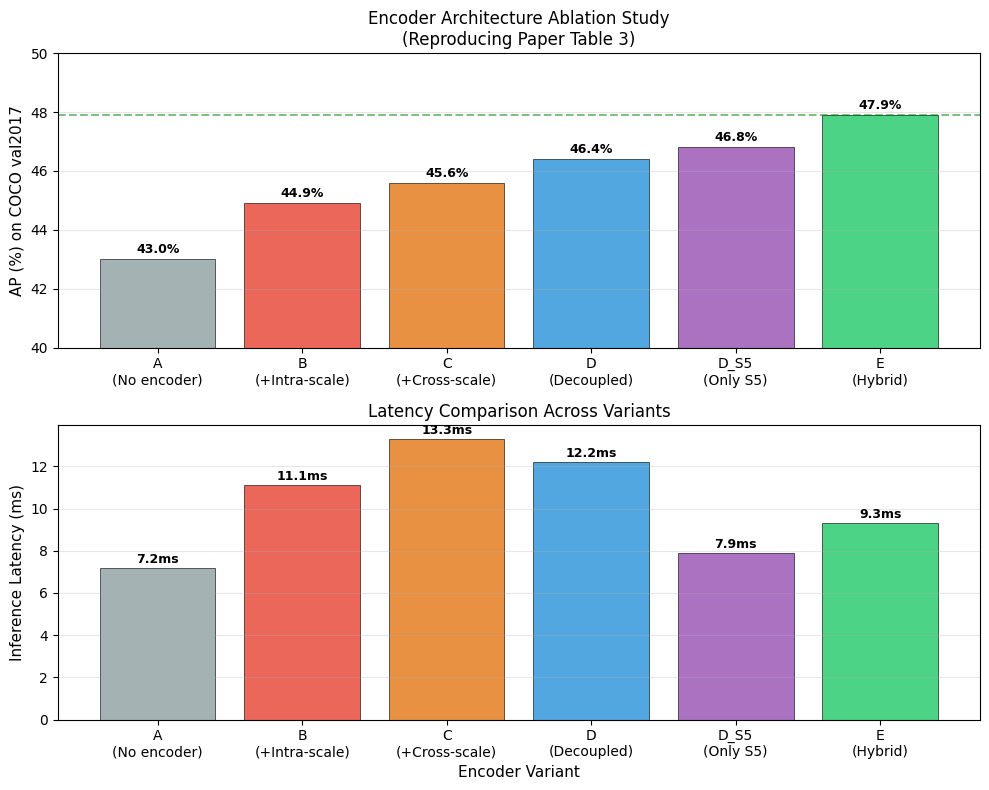

Ablation study chart saved!


In [11]:
# Reproduce Table 3 from the paper - Encoder variant ablation
variants = ['A\n(No encoder)', 'B\n(+Intra-scale)', 'C\n(+Cross-scale)', 
            'D\n(Decoupled)', 'D_S5\n(Only S5)', 'E\n(Hybrid)']
ap_scores = [43.0, 44.9, 45.6, 46.4, 46.8, 47.9]
latency_ms = [7.2, 11.1, 13.3, 12.2, 7.9, 9.3]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

colors = ['#gray' if i < 5 else '#2ECC71' for i in range(6)]
colors = ['#95A5A6', '#E74C3C', '#E67E22', '#3498DB', '#9B59B6', '#2ECC71']

bars = ax1.bar(variants, ap_scores, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('AP (%) on COCO val2017', fontsize=11)
ax1.set_title('Encoder Architecture Ablation Study\n(Reproducing Paper Table 3)', fontsize=12)
ax1.set_ylim(40, 50)
for bar, val in zip(bars, ap_scores):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, 
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=47.9, color='green', linestyle='--', alpha=0.5, label='Final model AP')

bars2 = ax2.bar(variants, latency_ms, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Inference Latency (ms)', fontsize=11)
ax2.set_xlabel('Encoder Variant', fontsize=11)
ax2.set_title('Latency Comparison Across Variants', fontsize=12)
for bar, val in zip(bars2, latency_ms):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, 
             f'{val}ms', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()
print("Ablation study chart saved!")

In [12]:
import os

base = "/kaggle/working"

hits = []

for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith((".mp4", ".avi")):
            hits.append(os.path.join(root, f))

print("\n".join(hits) if hits else "❌ NO VIDEO FILE FOUND ANYWHERE")

/kaggle/working/demo_output_fixed.mp4
/kaggle/working/RT-DETR/rtdetr_pytorch/input_video.mp4
